# Paper's Pipeline

In [1]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import pearsonr, beta as _beta_dist

from leaspy.io.data import Data
from leaspy.models import JointModel
from leaspy.datasets import load_dataset

warnings.filterwarnings("ignore", category=UserWarning)

## Reference model (source of true $\theta$)

The reference model is fitted once on the original data. Its parameters play the role of **true $\theta$** for the
simulation study, every simulated dataset will be generated from this model.

In [2]:
M          = 20 # Number of simulations per condition
N          = 1000 # Number of samples per simulation 
N_ITER     = 5000   
N_PERSO    = 5000   
NB_EVENTS  = 1

In [3]:
# # Load original data and create visit parameters for simulation
# data = Data.from_dataframe(load_dataset("simulated_data_for_joint"), "joint")
# df_orig = data.to_dataframe()
# print(f"Original data: {df_orig.shape[0]} rows, {df_orig['ID'].nunique()} patients")

# # Visit parameters are automatically estimated from the original data.
# visit_params = {
#     "patient_number": N,
#     "visit_type": "random",
#     "data": data,
# }

In [4]:
visit_params = {
    "patient_number": N,
    "visit_type": "random",
    "first_visit_mean": -2.0,
    "first_visit_std":  1.0,
    "time_follow_up_mean": 6.0,
    "time_follow_up_std":  2.0,
    "distance_visit_mean": 0.083 * 3,
    "distance_visit_std":  0.042,
    "min_spacing_between_visits": 0.05,
} 
# WARNING: these parameters are not based on real data, but typically overestimate the number of visits 
# per patient to get more data points, which lead to less iterations needed to get stable results. 


In [5]:
REF_MODEL_PATH = os.path.join("..", "models", "PROACT_diag.json")
ref_model = JointModel.load(REF_MODEL_PATH)

FEATURES  = ref_model.features
SAVE_PATH = os.path.join("..", "output", "PROACT_diag_N=1000_M=50_Niter=6000_Nperso=2000.pkl")

# Extract observation model configuration from reference model
obs_model_y = ref_model.obs_models[0]
obs_model_name = obs_model_y.to_string()
print(f"Reference model observation model: {obs_model_name}")

theta_true = {
    k: v.detach().cpu().numpy().copy()
    for k, v in ref_model.parameters.items()
}

print("True parameters theta (reference model):")
for k, v in theta_true.items():
    print(f"  {k:25s}: {np.atleast_1d(v).tolist()}")

Reference model observation model: gaussian-diagonal
True parameters theta (reference model):
  betas_mean               : [[-0.087186299264431, -0.15066930651664734], [-0.2923087775707245, -0.18187998235225677], [-0.05541963130235672, -0.00681214639917016], [-0.13087637722492218, 0.2405453771352768], [0.004298572428524494, 0.009653146378695965], [-0.0005587200867012143, 0.04628577455878258], [-0.05828078091144562, -0.08755263686180115]]
  log_g_mean               : [2.6441023349761963, 0.4462902545928955, 0.43316829204559326, 2.601536989212036, 0.036286722868680954, -0.22109641134738922, -0.09708363562822342, -0.07754672318696976]
  log_rho_mean             : [0.5928239822387695]
  log_v0_mean              : [-2.9520318508148193, -1.7690728902816772, -1.4975686073303223, -3.120152235031128, -3.4377944469451904, -2.6761457920074463, -2.4442009925842285, -2.8591079711914062]
  n_log_nu_mean            : [-1.5379470586776733]
  noise_std                : [0.06728087365627289, 0.192327335

## Simulation study loop

For each repetition m = 1, …, M:
1. Simulate a dataset of N patients from the reference model.
2. Fit a fresh `JointModel` on this simulated dataset.
3. Personalise to recover individual parameters.

In [6]:
from IPython.utils import io

with io.capture_output() as captured:
    if os.path.exists(SAVE_PATH):
        with open(SAVE_PATH, "rb") as f:
            results = pickle.load(f)
        # backward-compat: older pickles may not have ref_ips
        if "ref_ips" not in results:
            results["ref_ips"] = [None] * len(results["pop_params"])
        print(f"Loaded {len(results['pop_params'])} results from {SAVE_PATH}")
    else:
        results = {
            "pop_params": [],   # list of M dicts {param_name: np.ndarray}
            "true_ips":   [],   # list of M DataFrames with columns xi, tau (from simulation)
            "ref_ips":    [],   # list of M DataFrames: ref_model personalised on sim_data (oracle)
            "est_ips":    [],   # list of M DataFrames with columns xi, tau (from personalisation with new_model)
        }

        # Number of digits needed so zero-padded IDs sort lexicographically == numerically.
        # e.g. N=50 → 2 digits: "00","01",...,"49"  (avoids "0","1","10","11",... ordering)
        _n_digits = len(str(N - 1))

        for m in tqdm(range(M), desc="Simulation study"):

            # Simulate a dataset with the reference model
            np.random.seed(m)
            torch.manual_seed(m)

            sim_result = ref_model.simulate(
                algorithm="joint_simulate",
                features=FEATURES,
                visit_parameters=visit_params,
            )
            sim_data = sim_result.data

            # Rename IDs to zero-padded strings so that groupby("ID").min() inside
            # JointModel's Weibull initialisation produces the same patient order as
            # dataset.event_time (which uses insertion order).
            _df_sim = sim_data.to_dataframe()
            _id_map = {old: old.zfill(_n_digits) for old in _df_sim["ID"].unique()}
            _df_sim["ID"] = _df_sim["ID"].map(_id_map)
            sim_data = Data.from_dataframe(_df_sim, "joint", factory_kws={"nb_events": NB_EVENTS})

            # individual_parameters from simulate is a DataFrame [xi, tau, ...]
            ip_sim = sim_result.individual_parameters
            true_ip_df = ip_sim if isinstance(ip_sim, pd.DataFrame) else pd.DataFrame(ip_sim)
            true_ip_df.index = true_ip_df.index.map(lambda x: x.zfill(_n_digits))

            # Oracle: personalise with the TRUE reference model (known θ).
            # Computed here (only needs ref_model), but appended to results below
            # alongside true_ips/est_ips to keep all lists in sync.
            ref_ip_df = None
            try:
                ref_ip = ref_model.personalize(
                    sim_data, "mean_posterior",
                    seed=3000 + m, n_iter=N_PERSO, progress_bar=False,
                )
                ref_ip_df = ref_ip.to_dataframe()
            except Exception as exc:
                print(f"  [m={m}] Oracle personalisation failed: {exc}")

            # Fit a new model on the simulated data to recover population parameters
            # Use the same observation model as the reference model
            new_model = JointModel(
                name=f"m{m}",
                nb_events=NB_EVENTS,
                dimension=ref_model.dimension,
                source_dimension=ref_model.source_dimension,
                obs_models=obs_model_name,
            )
            try:
                new_model.fit(
                    sim_data, "mcmc_saem",
                    seed=1000 + m, n_iter=N_ITER, progress_bar=False,
                )
            except Exception as exc:
                print(f"  [m={m}] Fit failed: {exc}")
                continue   # ref_ip_df not yet appended — all lists stay in sync
            est_params = {
                k: v.detach().cpu().numpy().copy()
                for k, v in new_model.parameters.items()
            }
            results["pop_params"].append(est_params)

            # Personalise the new model to recover individual parameters.
            # ref_ips is appended here (same place as true_ips / est_ips) so all
            # four lists always have the same length.
            try:
                est_ip = new_model.personalize(
                    sim_data, "mean_posterior",
                    seed=2000 + m, n_iter=N_PERSO, progress_bar=False,
                )
                results["est_ips"].append(est_ip.to_dataframe())
                results["true_ips"].append(true_ip_df)
                results["ref_ips"].append(ref_ip_df)
            except Exception as exc:
                print(f"  [m={m}] Personalisation failed: {exc}")
                results["est_ips"].append(None)
                results["true_ips"].append(None)
                results["ref_ips"].append(ref_ip_df)

        with open(SAVE_PATH, "wb") as f:
            pickle.dump(results, f)
        print(f"Results saved to {SAVE_PATH}")

## Model parameter metrics (RB, RRMSE, REE, RSE)

$$
REE(m) = \frac{\hat{\theta}^{(m)}-\theta}{\theta} \times 100 \qquad
RB(\hat\theta) = \frac{1}{M}\sum_m REE(m) \qquad
RRMSE(\hat\theta) = \sqrt{\frac{1}{M}\sum_m REE(m)^2}
$$

$$
SE_{emp}(\hat\theta) = \sqrt{\frac{\sum_m(\hat\theta^{(m)}-\bar{\hat\theta})^2}{M-1}}
\qquad
RSE_{emp}(\hat\theta) = \frac{SE_{emp}(\hat\theta)}{\bar{\hat\theta}}
$$

In [7]:
def clopper_pearson_ci(k, n, alpha=0.05):
    """Exact Clopper-Pearson 95% CI for a binomial proportion k/n."""
    lo = _beta_dist.ppf(alpha / 2,     k,     n - k + 1) if k > 0 else 0.0
    hi = _beta_dist.ppf(1 - alpha / 2, k + 1, n - k    ) if k < n else 1.0
    return lo, hi


def compute_metrics(theta_true_val, theta_hats, se_hats=None):
    """
    Compute RB, RRMSE and RSE for a scalar estimand.
    Optionally computes coverage rate (CR) if se_hats is provided.
    RB / RRMSE / REE are in %; RSE is a dimensionless ratio.
    """
    theta_hats = np.asarray(theta_hats, dtype=float)

    ree    = (theta_hats - theta_true_val) / abs(theta_true_val) * 100
    rb     = float(ree.mean())
    rrmse  = float(np.sqrt((ree ** 2).mean()))
    se_emp = float(theta_hats.std(ddof=1))
    rse    = float(se_emp / abs(theta_hats.mean()))

    out = {"REE": ree, "RB": rb, "RRMSE": rrmse, "RSE": rse}

    if se_hats is not None:
        se_hats = np.asarray(se_hats, dtype=float)
        covered = (
            (theta_hats - 1.96 * se_hats <= theta_true_val) &
            (theta_true_val <= theta_hats + 1.96 * se_hats)
        )
        k = int(covered.sum())
        lo, hi = clopper_pearson_ci(k, len(theta_hats))
        out.update({"CR": k / len(theta_hats), "CR_lo": lo, "CR_hi": hi})

    return out


In [8]:
PARAM_LABELS = {
    "xi_std":        r"$\sigma_{\xi}$",
    "tau_mean":      r"$t_0$",
    "tau_std":       r"$\sigma_{\tau}$",
    "noise_std":     r"$\sigma$",
    "g":             r"$\tilde{g}$",
    "log_v0":        r"$\tilde{v}_0$",
    "n_log_nu_mean": r"$\tilde{\nu}$",
    "log_rho_mean":  r"$\tilde{\rho}$",
    "log_g_mean":    r"$\tilde{g}$",
    "log_v0_mean":   r"$\tilde{v}_0$",
}

# betas_mean and zeta_mean share a rotational non-identifiability with `sources`:
# any O(source_dimension) rotation of the source space leaves space_shifts and
# survival_shifts unchanged while rotating betas_mean and zeta_mean arbitrarily.
# Component-wise REE/RB is therefore meaningless for these two parameters.
# We replace them with their Frobenius norms, which ARE rotation-invariant:
#   ||betas_mean||_F  and  ||zeta_mean||
NON_IDENTIFIABLE_PARAMS = {"betas_mean", "zeta_mean"}
NORM_PARAM_LABELS = {
    "betas_mean": r"$\|\beta\|_F$",
    "zeta_mean":  r"$\|\zeta\|$",
}

summary_rows = []
ree_dict     = {}
ree_groups   = {}  # {param_name: {label: ree_array}}

for param_name, theta_true_arr in theta_true.items():
    if param_name in NON_IDENTIFIABLE_PARAMS:
        continue  # handled separately below via Frobenius norm

    theta_true_flat = np.atleast_1d(np.array(theta_true_arr).ravel())

    # Collect estimates from each simulation
    hats_list = [
        np.atleast_1d(np.array(r[param_name]).ravel())
        for r in results["pop_params"]
        if r is not None and param_name in r
    ]
    if not hats_list:
        continue
    hats_mat = np.array(hats_list)   # (M_actual, d)

    label_base = PARAM_LABELS.get(param_name, param_name)

    if len(theta_true_flat) == 1:
        t = float(theta_true_flat[0])
        if abs(t) < 1e-10:
            continue
        hat_vec = hats_mat[:, 0]
        label = label_base
    else:
        t = float(theta_true_flat.mean())
        if abs(t) < 1e-10:
            continue
        hat_vec = hats_mat.mean(axis=1)
        label = f"{label_base} (mean)"

    mets = compute_metrics(t, hat_vec)
    summary_rows.append({
        "Parameter":       label,
        "theta (true)":    round(t, 5),
        "theta mean (M)":  round(float(hat_vec.mean()), 5),
        "RB (%)":          round(mets["RB"],    3),
        "RRMSE (%)":       round(mets["RRMSE"], 3),
        "RSE":             round(mets["RSE"],   4),
    })
    ree_dict[label] = mets["REE"]
    ree_groups.setdefault(param_name, {})[label] = mets["REE"]

# --- Identifiable summaries for non-identifiable parameters ---
for param_name, norm_label in NORM_PARAM_LABELS.items():
    if param_name not in theta_true:
        continue
    t_norm = float(np.linalg.norm(np.array(theta_true[param_name]).ravel()))
    if t_norm < 1e-10:
        continue
    hat_norms = np.array([
        np.linalg.norm(np.array(r[param_name]).ravel())
        for r in results["pop_params"]
        if r is not None and param_name in r
    ])
    if len(hat_norms) == 0:
        continue
    mets = compute_metrics(t_norm, hat_norms)
    summary_rows.append({
        "Parameter":       norm_label,
        "theta (true)":    round(t_norm, 5),
        "theta mean (M)":  round(float(hat_norms.mean()), 5),
        "RB (%)":          round(mets["RB"],    3),
        "RRMSE (%)":       round(mets["RRMSE"], 3),
        "RSE":             round(mets["RSE"],   4),
    })
    ree_dict[norm_label] = mets["REE"]
    ree_groups.setdefault(param_name, {})[norm_label] = mets["REE"]

df_metrics = pd.DataFrame(summary_rows)
display(df_metrics)


,Parameter,theta (true),theta mean (M),RB (%),RRMSE (%),RSE
0,$\tilde{g}$ (mean),0.72071,0.61212,-15.067,15.869,0.0593
1,$\tilde{\rho}$,0.59282,0.53484,-9.781,12.072,0.0792
2,$\tilde{v}_0$ (mean),-2.59451,-2.57348,0.811,1.709,0.0153
3,$\tilde{\nu}$,-1.53795,-1.54428,-0.412,2.394,0.0237
4,$\sigma$ (mean),0.11372,0.11089,-2.481,2.494,0.0026
5,$t_0$,57.23033,57.76175,0.929,1.239,0.0082
6,$\sigma_{\tau}$,11.81645,11.83670,0.171,2.305,0.0232
7,$\sigma_{\xi}$,1.19113,1.20722,1.351,3.095,0.0278
8,$\|\beta\|_F$,0.49016,0.44724,-8.756,8.916,0.0186
9,$\|\zeta\|$,0.24179,0.20067,-17.004,23.327,0.1944


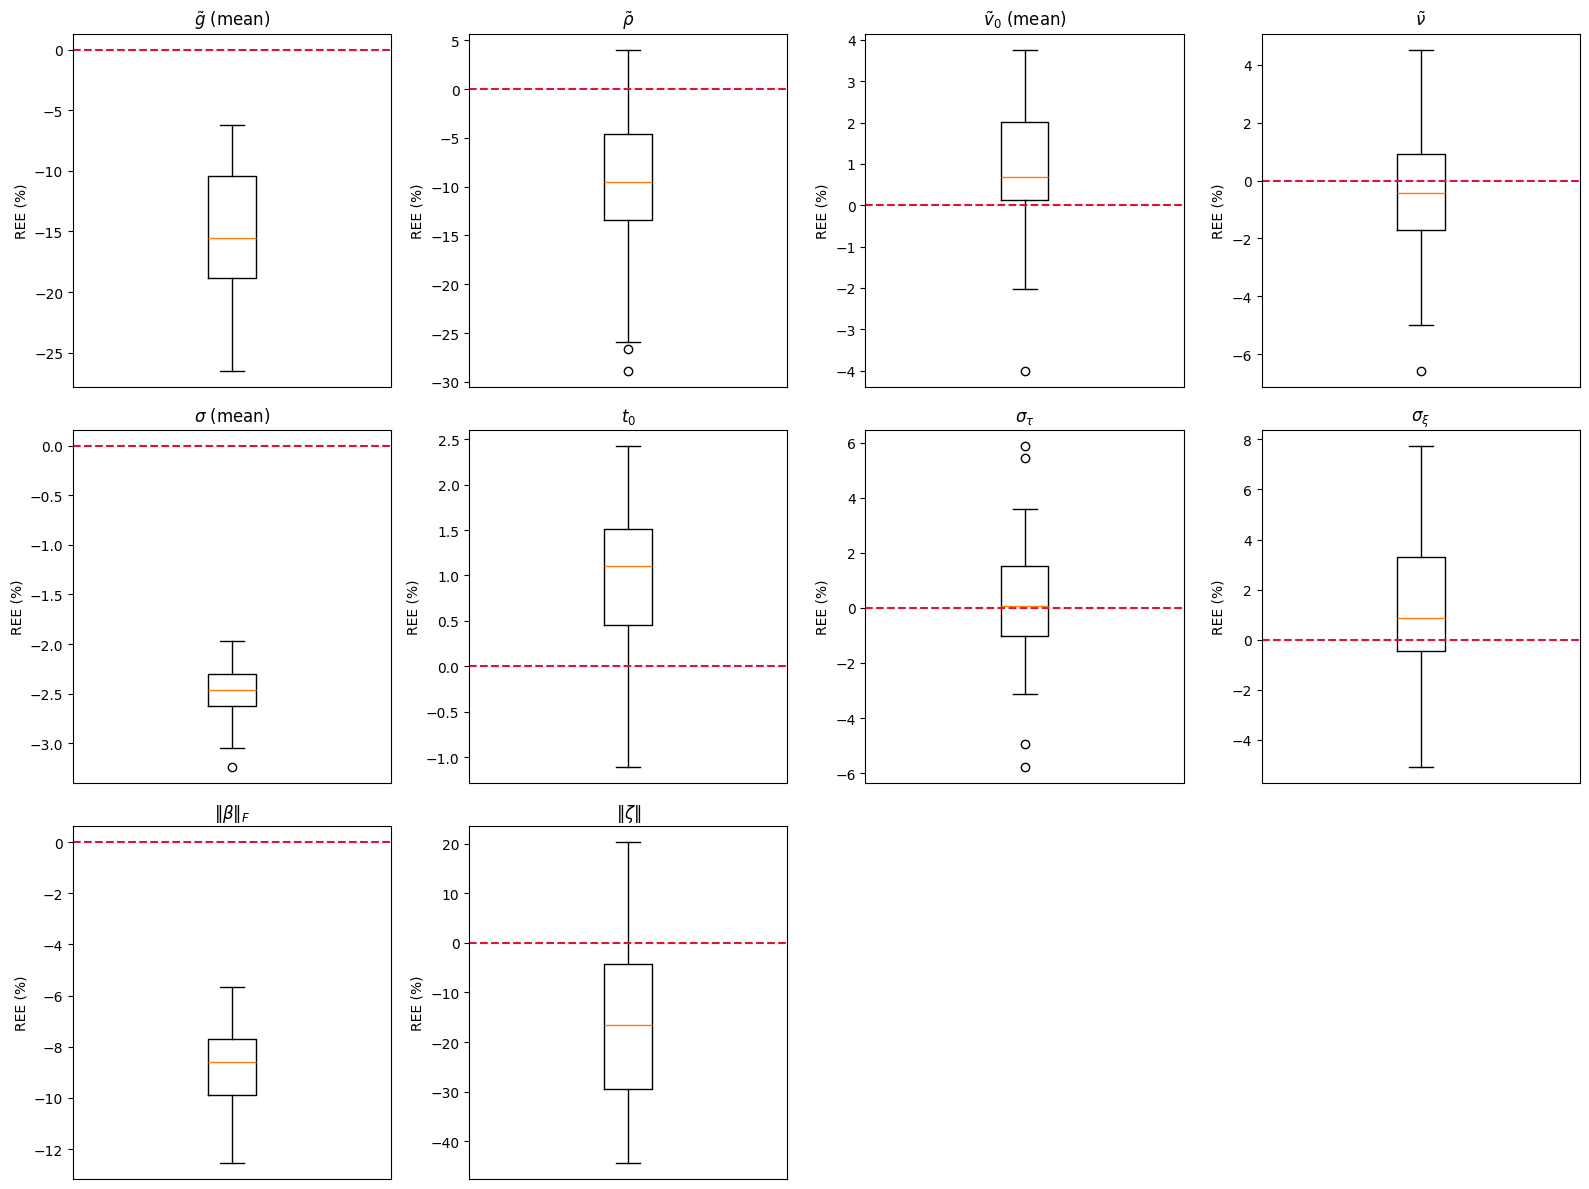

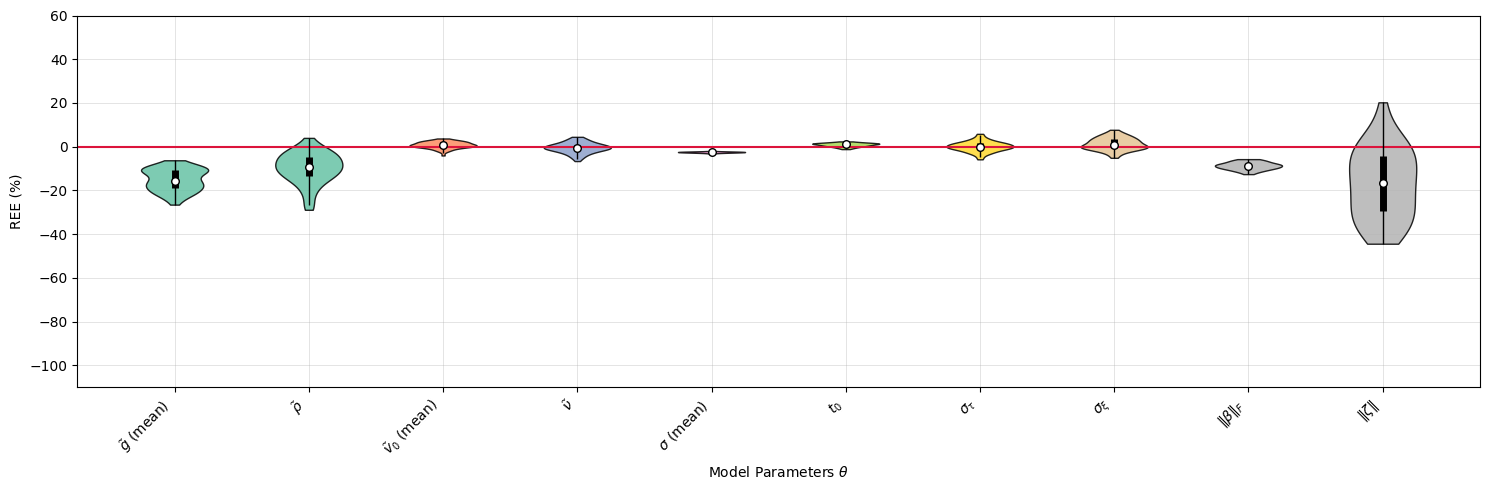

In [9]:
if ree_dict:
    n_params = len(ree_dict)
    ncols = min(4, n_params)
    nrows = (n_params + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).ravel()

    for ax, (label, ree_vals) in zip(axes, ree_dict.items()):
        ax.boxplot([ree_vals], vert=True)
        ax.axhline(0, color="crimson", linestyle="--", lw=1.5)
        ax.set_ylabel("REE (%)")
        ax.set_title(label)
        ax.set_xticks([])

    for ax in axes[n_params:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

    # --- Second figure: vertical violin plot, all parameters, same scale ---
    all_labels = list(ree_dict.keys())
    all_data = [ree_dict[label] for label in all_labels]
    n_params = len(all_labels)

    colors = plt.cm.Set2(np.linspace(0, 1, n_params))

    fig2, ax2 = plt.subplots(figsize=(max(1.5 * n_params, 6), 5))

    parts = ax2.violinplot(
        all_data,
        positions=range(n_params),
        vert=True,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for i, pc in enumerate(parts["bodies"]):
        pc.set_facecolor(colors[i])
        pc.set_edgecolor("black")
        pc.set_linewidth(1)
        pc.set_alpha(0.85)

    # overlay mini box-plot + median dot
    for i, data in enumerate(all_data):
        q1, med, q3 = np.percentile(data, [25, 50, 75])
        iqr = q3 - q1
        whisker_lo = max(np.min(data), q1 - 1.5 * iqr)
        whisker_hi = min(np.max(data), q3 + 1.5 * iqr)

        # thick bar for IQR
        ax2.vlines(i, q1, q3, color="black", linewidth=5, zorder=3)
        # thin line for whiskers
        ax2.vlines(i, whisker_lo, whisker_hi, color="black", linewidth=1, zorder=3)
        # white dot for median
        ax2.scatter(i, med, color="white", edgecolor="black", s=30, zorder=4)

    ax2.axhline(0, color="crimson", linewidth=1.5, zorder=2)
    ax2.set_xticks(range(n_params))
    ax2.set_xticklabels(all_labels, rotation=45, ha="right")
    ax2.set_xlabel(r"Model Parameters $\theta$")
    ax2.set_ylabel("REE (%)")
    ax2.grid(True, axis="both", linestyle="-", linewidth=0.4, alpha=0.6)
    ax2.set_axisbelow(True)
    ax2.set_ylim(bottom=min(-110, min(np.min(data) for data in all_data)), top=max(60, max(np.max(data) for data in all_data))) 

    plt.tight_layout()
    plt.show()

## Random effects: ICC 

The estimation of the random effects is assessed using the **intraclass correlation**
between the personalised values and the true values used for simulation.

We use ICC(3,1) — two-way mixed-effects model, single rater, absolute agreement:

$$ICC(3,1) = \frac{MS_B - MS_E}{MS_B + (k-1)\,MS_E}, \quad k=2$$

For reference, the Pearson correlation (which measures association but not agreement) is also reported.

x var       y var       IP         ICC(3,1)     Pearson r
-------------------------------------------------------
true_ips    est_ips     xi     0.987 +/- 0.004  0.988 +/- 0.004
true_ips    est_ips     tau    0.994 +/- 0.002  0.995 +/- 0.002


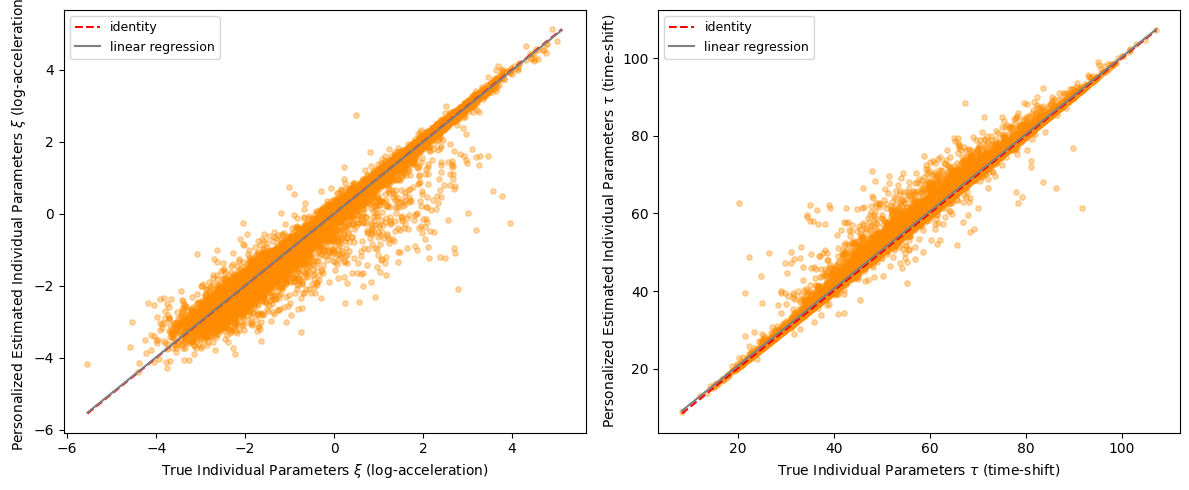

ref_ips     est_ips     xi     0.996 +/- 0.002  0.996 +/- 0.002
ref_ips     est_ips     tau    0.996 +/- 0.002  0.996 +/- 0.001


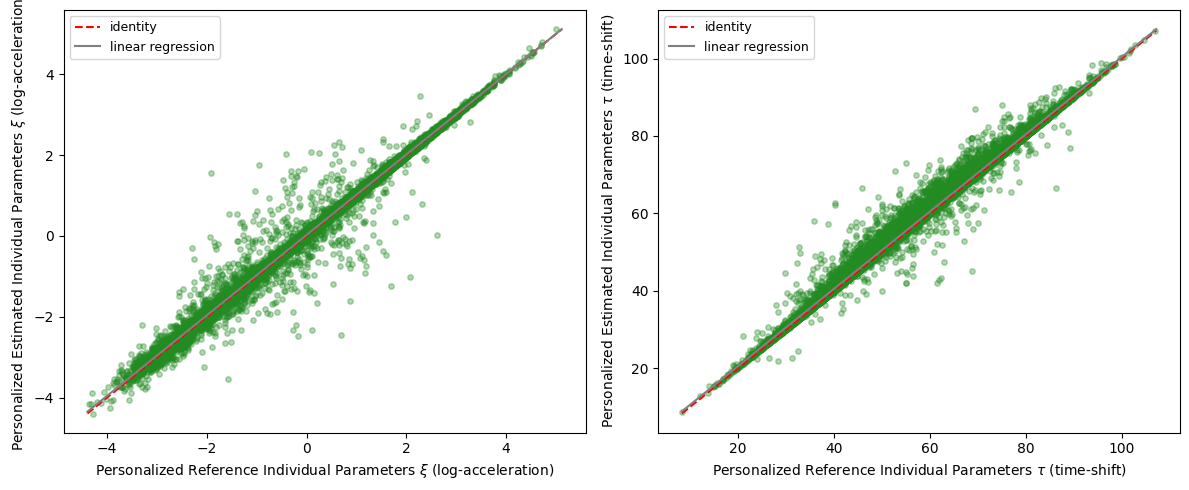

true_ips    ref_ips     xi     0.988 +/- 0.004  0.988 +/- 0.003
true_ips    ref_ips     tau    0.997 +/- 0.001  0.997 +/- 0.001


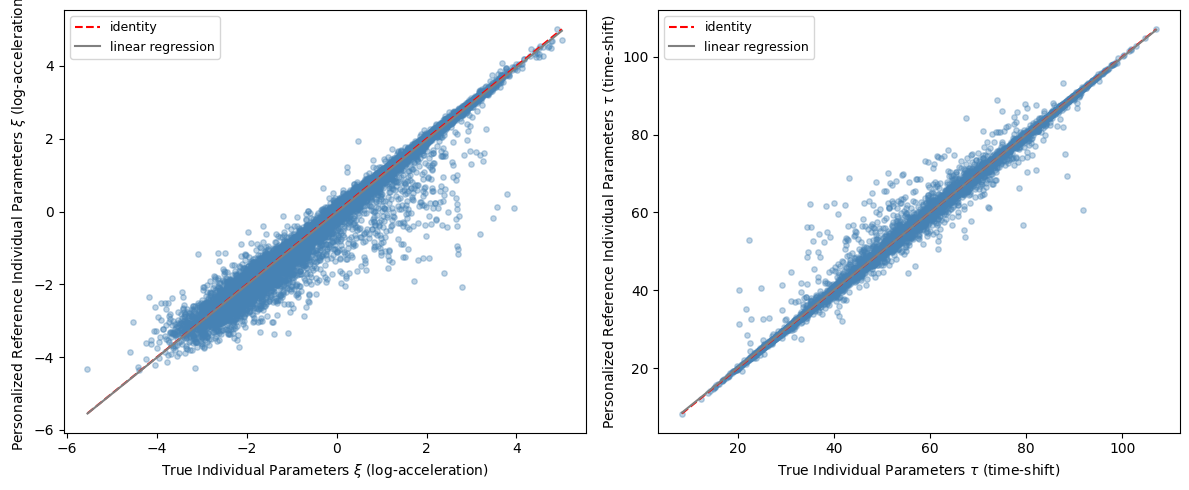

In [10]:
def icc_3_1(y_true, y_hat):
    """ICC(3,1) — two-way mixed-effects, k=2 raters, absolute agreement."""
    y_true = np.asarray(y_true, dtype=float)
    y_hat  = np.asarray(y_hat,  dtype=float)
    n = len(y_true)
    if n < 3:
        return float("nan")
    k = 2
    y = np.stack([y_true, y_hat], axis=1)   # (n, 2)
    grand_mean = y.mean()
    row_means  = y.mean(axis=1)             # subject means
    ss_b = k * np.sum((row_means - grand_mean) ** 2)
    ss_e = np.sum((y - row_means[:, None]) ** 2)
    ms_b = ss_b / (n - 1)
    ms_e = ss_e / (n * (k - 1))
    return float((ms_b - ms_e) / (ms_b + (k - 1) * ms_e))


valid_pairs = [
    (t, e)
    for t, e in zip(results["true_ips"], results["est_ips"])
    if t is not None and e is not None
]
valid_ref_pairs = [
    (t, r)
    for t, r in zip(results["true_ips"], results["ref_ips"])
    if t is not None and r is not None
]
valid_ref_est_pairs = [
    (r, e)
    for r, e in zip(results["ref_ips"], results["est_ips"])
    if r is not None and e is not None
]

ip_cols  = ["xi", "tau"]
ip_latex = [r"$\xi$", r"$\tau$"]
ip_descs = ["log-acceleration", "time-shift"]

label_map = {
    "true_ips": "True Individual Parameters",
    "ref_ips":  "Personalized Reference Individual Parameters",
    "est_ips":  "Personalized Estimated Individual Parameters",
}

# (x_var, y_var, pairs, colour)
comparisons = [
    ("true_ips", "est_ips", valid_pairs,         "darkorange"),
    ("ref_ips",  "est_ips", valid_ref_est_pairs,  "forestgreen"),
    ("true_ips", "ref_ips", valid_ref_pairs,      "steelblue"),
]

if not any(pairs for _, _, pairs, _ in comparisons):
    print("No valid personalisation results — ICC cannot be computed.")
else:
    print(f"{'x var':10s}  {'y var':10s}  {'IP':5s}  {'ICC(3,1)':>12s}  {'Pearson r':>12s}")
    print("-" * 55)

    for row_idx, (x_var, y_var, pairs, cmp_color) in enumerate(comparisons):
        if not pairs:
            continue

        # --- One figure per comparison row, with both IP columns side by side ---
        fig, axes = plt.subplots(1, len(ip_cols), figsize=(6 * len(ip_cols), 5))

        for col_idx, (col, col_latex, col_desc) in enumerate(zip(ip_cols, ip_latex, ip_descs)):
            ax = axes[col_idx]
            icc_vals, r_vals = [], []
            all_x, all_y = [], []

            for x_df, y_df in pairs:
                common = x_df.index.astype(str).intersection(y_df.index.astype(str))
                if len(common) < 3:
                    continue
                xv = x_df.loc[x_df.index.astype(str).isin(common), col].to_numpy(dtype=float)
                yv = y_df.loc[y_df.index.astype(str).isin(common), col].to_numpy(dtype=float)
                all_x.append(xv)
                all_y.append(yv)
                icc_vals.append(icc_3_1(xv, yv))
                if np.std(xv) > 0 and np.std(yv) > 0:
                    r_vals.append(pearsonr(xv, yv)[0])

            ax_x = np.concatenate(all_x)
            ax_y = np.concatenate(all_y)

            ax.scatter(ax_x, ax_y, alpha=0.35, s=15, color=cmp_color)
            lo, hi = min(ax_x.min(), ax_y.min()), max(ax_x.max(), ax_y.max())
            ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="identity")

            slope, intercept = np.polyfit(ax_x, ax_y, 1)
            ax.plot(
                [lo, hi],
                [slope * lo + intercept, slope * hi + intercept],
                color="grey", lw=1.5, label="linear regression",
            )

            x_label = label_map[x_var]
            y_label = label_map[y_var]

            ax.set_xlabel(f"{x_label} {col_latex} ({col_desc})")
            ax.set_ylabel(f"{y_label} {col_latex} ({col_desc})")
            ax.legend(fontsize=9)

            icc_m = np.nanmean(icc_vals)
            icc_s = np.nanstd(icc_vals)
            r_m   = np.nanmean(r_vals) if r_vals else float("nan")
            r_s   = np.nanstd(r_vals)  if r_vals else float("nan")
            print(f"{x_var:10s}  {y_var:10s}  {col:5s}  {icc_m:.3f} +/- {icc_s:.3f}  {r_m:.3f} +/- {r_s:.3f}")

        plt.tight_layout()
        plt.show()

## Random effects: Bland-Altman

The Bland-Altman plot is the standard complement to ICC for method-comparison studies.
It plots the **difference** $\hat\theta_i - \theta_i^{true}$ against the **mean**
$\frac{\hat\theta_i + \theta_i^{true}}{2}$, pooled across all $M$ simulations.

Key quantities shown:
- **Bias** (mean difference, solid line): systematic over- or under-estimation
- **Limits of agreement** $\pm 1.96\,\text{SD}$ (dashed lines): range that captures ~95 % of individual differences

x var       y var       IP           Bias     LoA lower     LoA upper
-----------------------------------------------------------------
true_ips    est_ips     xi        -0.0007       -0.3722       +0.3708
true_ips    est_ips     tau       +0.4974       -1.8326       +2.8274


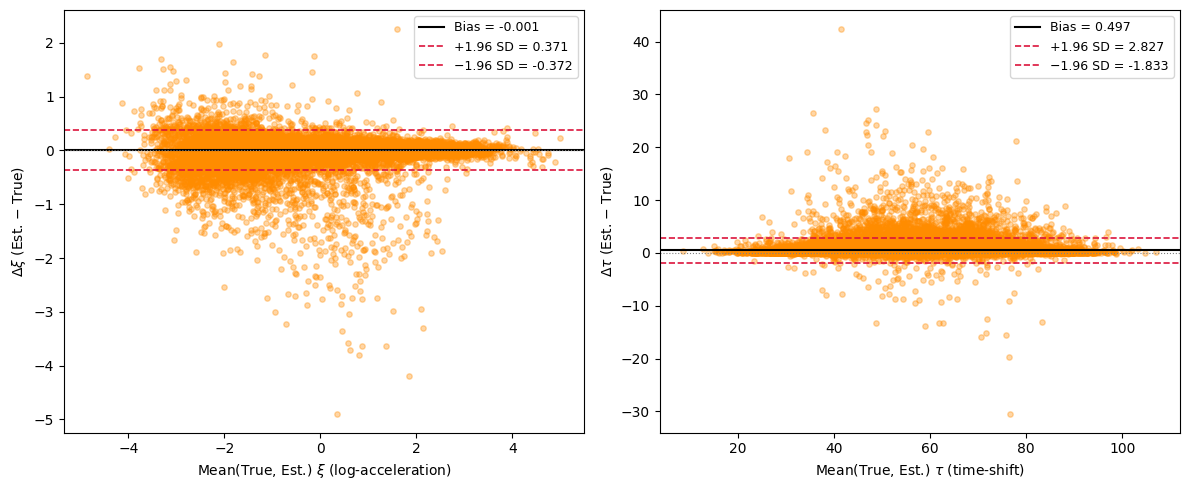

ref_ips     est_ips     xi        +0.0243       -0.1921       +0.2407
ref_ips     est_ips     tau       +0.4665       -1.5326       +2.4656


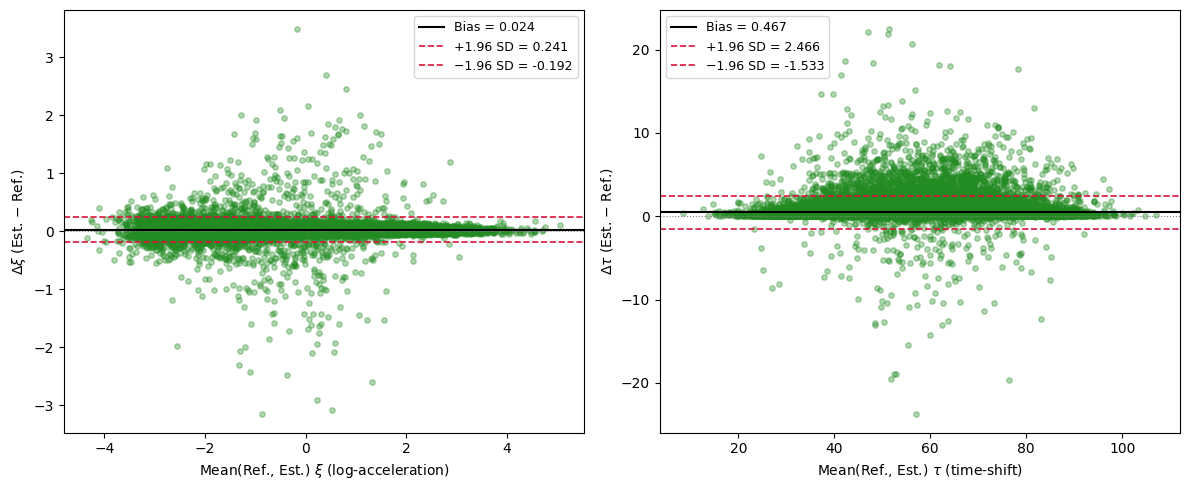

true_ips    ref_ips     xi        -0.0250       -0.3856       +0.3356
true_ips    ref_ips     tau       +0.0309       -1.6104       +1.6721


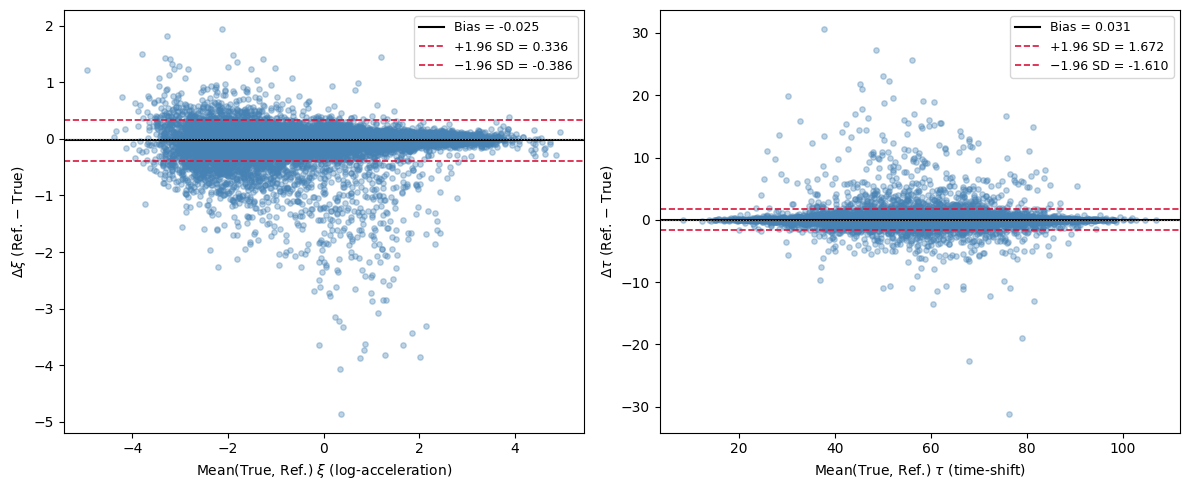

In [11]:
if not any([valid_pairs, valid_ref_pairs, valid_ref_est_pairs]):
    print("No valid personalisation results — Bland-Altman cannot be computed.")
else:
    ip_cols  = ["xi", "tau"]
    ip_latex = [r"$\xi$", r"$\tau$"]
    ip_descs = ["log-acceleration", "time-shift"]

    short_label = {
        "true_ips": "True",
        "ref_ips":  "Ref.",
        "est_ips":  "Est.",
    }

    # (x_var, y_var, pairs, colour)
    comparisons = [
        ("true_ips", "est_ips", valid_pairs,         "darkorange"),
        ("ref_ips",  "est_ips", valid_ref_est_pairs,  "forestgreen"),
        ("true_ips", "ref_ips", valid_ref_pairs,      "steelblue"),
    ]

    print(f"{'x var':10s}  {'y var':10s}  {'IP':5s}  {'Bias':>10s}  {'LoA lower':>12s}  {'LoA upper':>12s}")
    print("-" * 65)

    for row_idx, (x_var, y_var, pairs, cmp_color) in enumerate(comparisons):
        if not pairs:
            continue

        fig, axes = plt.subplots(1, len(ip_cols), figsize=(6 * len(ip_cols), 5))

        for col_idx, (col, col_latex, col_desc) in enumerate(zip(ip_cols, ip_latex, ip_descs)):
            ax = axes[col_idx]
            all_mean, all_diff = [], []

            for x_df, y_df in pairs:
                common = x_df.index.astype(str).intersection(y_df.index.astype(str))
                if len(common) < 3:
                    continue
                xv = x_df.loc[x_df.index.astype(str).isin(common), col].to_numpy(dtype=float)
                yv = y_df.loc[y_df.index.astype(str).isin(common), col].to_numpy(dtype=float)
                all_mean.append((xv + yv) / 2.0)
                all_diff.append(yv - xv)

            means = np.concatenate(all_mean)
            diffs = np.concatenate(all_diff)
            bias   = float(diffs.mean())
            sd     = float(diffs.std(ddof=1))
            loa_lo = bias - 1.96 * sd
            loa_hi = bias + 1.96 * sd

            xl = short_label[x_var]
            yl = short_label[y_var]

            ax.scatter(means, diffs, alpha=0.35, s=15, color=cmp_color)
            ax.axhline(bias,   color="black",   lw=1.5, linestyle="-",  label=f"Bias = {bias:.3f}")
            ax.axhline(loa_hi, color="crimson", lw=1.2, linestyle="--", label=f"+1.96 SD = {loa_hi:.3f}")
            ax.axhline(loa_lo, color="crimson", lw=1.2, linestyle="--", label=f"−1.96 SD = {loa_lo:.3f}")
            ax.axhline(0, color="grey", lw=0.8, linestyle=":")
            ax.set_xlabel(f"Mean({xl}, {yl}) {col_latex} ({col_desc})")
            ax.set_ylabel(f"Δ{col_latex} ({yl} − {xl})")
            ax.legend(fontsize=9)

            print(f"{x_var:10s}  {y_var:10s}  {col:5s}  {bias:+10.4f}  {loa_lo:+12.4f}  {loa_hi:+12.4f}")

        plt.tight_layout()
        plt.show()

## Example simulated trajectories

Longitudinal feature trajectories for a handful of patients drawn from one simulated dataset.
Time is expressed **relative to each patient's individual time-shift** $\tau_i$, so all trajectories are centred around the same disease reference point (dotted black line at 0).

Each plot element:
- **Smooth curve** — the true noiseless latent trajectory $f(t;\,\theta,\,\xi_i,\tau_i)$, a monotonically increasing logistic S-curve
- **Dots** — the actual simulated observations, each drawn independently from $\text{Beta}(\alpha_{ij}, \beta_{ij})$ centred on the latent value; scatter around the curve reflects the measurement noise ($\hat\sigma \approx 0.39$, fitted on the PULSE dataset)
- **Solid vertical line** — observed event time $T_i - \tau_i$ (patient experienced the event); no visits are recorded after this point
- **Dashed vertical line** — censored event time (patient did not experience the event within the follow-up window)



Simulate with `joint_simulate` took: 4s


,ID,TIME,EVENT_TIME,EVENT_BOOL,ALSFRS_R_BULBAR,ALSFRS_R_FINE_MOTOR,ALSFRS_R_GROSS_MOTOR
0,0,78.54,82.728748,0,4.286455e-10,0.404396,0.151205
1,0,78.79,82.728748,0,5.931900e-11,0.417096,0.349773
2,0,79.05,82.728748,0,1.213988e-06,0.655811,0.208600
3,0,79.27,82.728748,0,7.983769e-02,0.516265,0.274257
4,0,79.52,82.728748,0,3.834075e-02,0.590998,0.285740
...,...,...,...,...,...,...,...
91,4,70.91,71.892634,1,9.967078e-01,0.680729,0.956179
92,4,71.14,71.892634,1,9.948626e-01,0.812769,0.657632
93,4,71.35,71.892634,1,9.999999e-01,0.993888,0.999339
94,4,71.59,71.892634,1,1.000000e+00,0.999961,1.000000


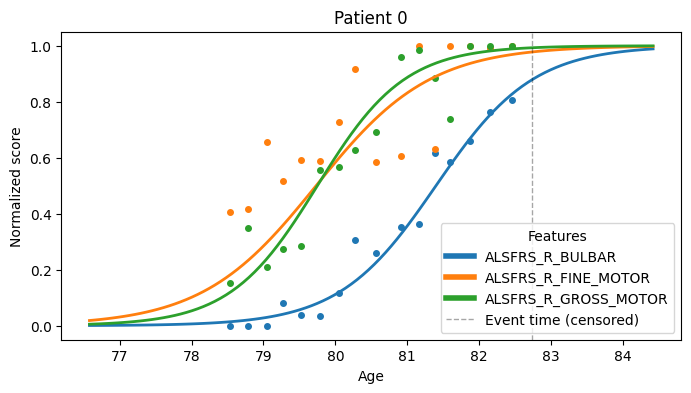

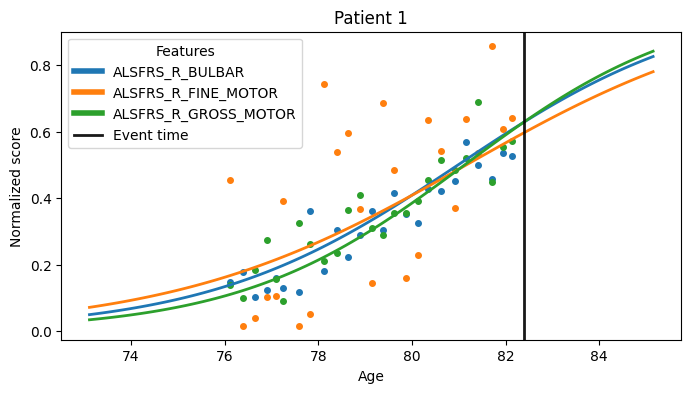

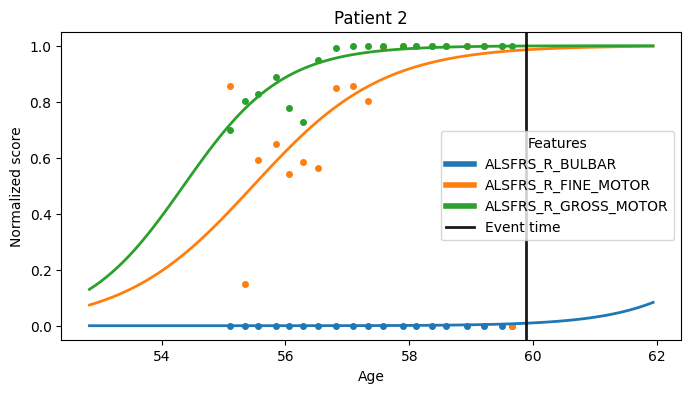

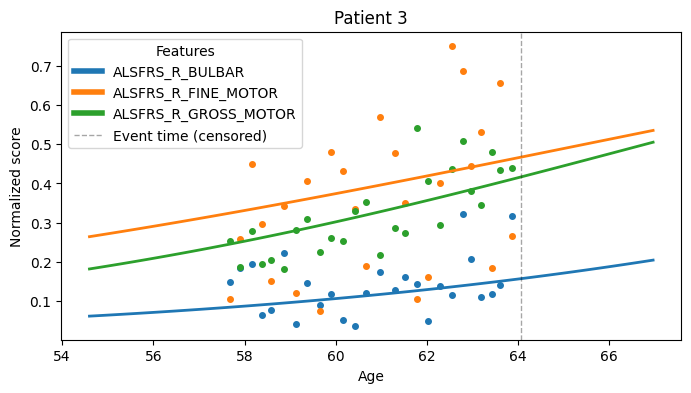

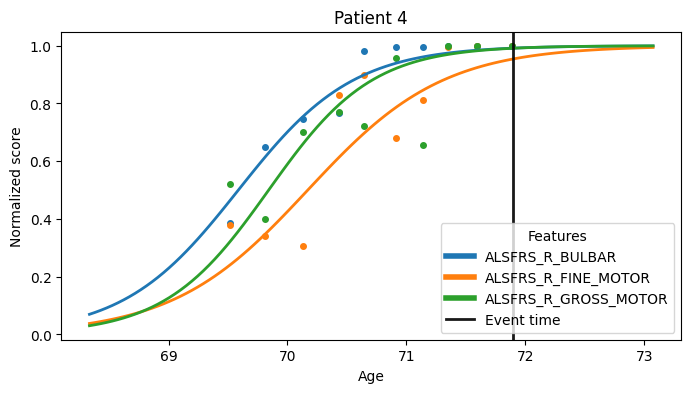

In [12]:
np.random.seed(12)
torch.manual_seed(12)

ex_result = ref_model.simulate(
    algorithm="joint_simulate",
    features=FEATURES,
    visit_parameters=visit_params,
)
df_ex = ex_result.data.to_dataframe()
ip_ex = ex_result.individual_parameters  # DataFrame with xi, tau, ...

evt_time_col = ex_result.data.event_time_name
evt_bool_col = ex_result.data.event_bool_name

from leaspy.io.logs.visualization.plotting import Plotting

ip_ex_named = ip_ex.copy()
ip_ex_named.index.name = "ID"

plotter = Plotting(ref_model)

N_SHOW = 5
shown_ids = df_ex["ID"].unique()[:N_SHOW]
first_3_features = FEATURES[:3]

display(df_ex[df_ex["ID"].isin(shown_ids)][["ID", "TIME", evt_time_col, evt_bool_col] + first_3_features])

for pid in shown_ids:
    ax = plotter.patient_trajectories(
        data=ex_result.data,
        individual_parameters=ip_ex_named,
        patients_idx=[pid],
        features=first_3_features,
    )
    ax.set_title(f"Patient {pid}")
    plt.show()